### 1. Importação de Bibliotecas
Configuramos o ambiente importando as ferramentas para manipulação de dados, pré-processamento, construção da rede neural e visualização.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

# Garantir reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

### 2. Criação da Base de Dados
Geramos 24 meses de dados de vendas fictícios.

In [2]:
meses = pd.date_range(start='2023-01-01', periods=24, freq='ME')
vendas = np.random.randint(80000, 120000, size=24) * 2
df = pd.DataFrame({'Mês': meses, 'Vendas': vendas})

display(df.head())

,Mês,Vendas
0,2023-01-31,191590
1,2023-02-28,161720
2,2023-03-31,236316
3,2023-04-30,182568
4,2023-05-31,172530


### 3. Separação e Pré-processamento
Como redes neurais não processam objetos de data diretamente, vamos converter as datas para valores numéricos ordinais antes da normalização.

In [9]:
# Converter datas para ordinais (numérico) para o modelo
X = df['Mês'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
y = df['Vendas'].values.reshape(-1, 1)

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalização de X e y
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

### 4. Construção e Treinamento do Modelo
Criamos uma rede densa com camadas de 64 e 32 neurônios.

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Treinamento com y normalizado
history = model.fit(X_train_scaled, y_train_scaled, epochs=200, verbose=0)
print("Treinamento concluído com alvos normalizados.")

Treinamento concluído com alvos normalizados.


### 5. Avaliação e Visualização
Comparamos as previsões do modelo com os dados reais de teste.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.5419
Loss (MSE Normalizado): 0.5418838262557983
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


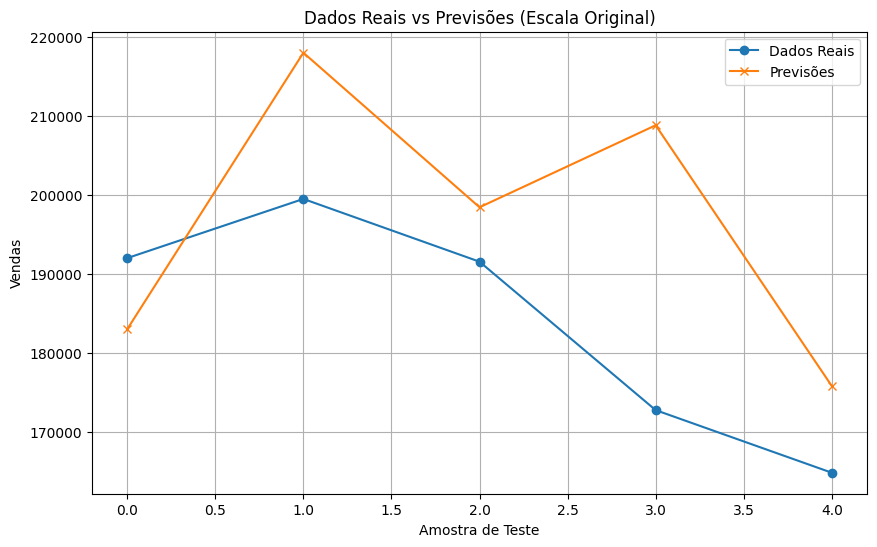

In [11]:
loss = model.evaluate(X_test_scaled, y_test_scaled)
print(f'Loss (MSE Normalizado): {loss}')

# Fazer previsões e desnormalizar para escala real
predictions_scaled = model.predict(X_test_scaled)
predictions = scaler_y.inverse_transform(predictions_scaled)

plt.figure(figsize=(10, 6))
plt.plot(y_test, 'o-', label='Dados Reais')
plt.plot(predictions, 'x-', label='Previsões')
plt.xlabel('Amostra de Teste')
plt.ylabel('Vendas')
plt.title('Dados Reais vs Previsões (Escala Original)')
plt.legend()
plt.grid(True)
plt.show()